In [268]:
# %load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.data_qc import *
from scripts.poke_detection import *

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [286]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_11_adc_debug"

session_index = build_sessions_index(data_dir)

In [287]:
session_index

session_id,x_um,y_um,date_yyyymmdd,time_hhmm,total_captured_sweeps,saved_sweeps,sweeps_per_block,samples_per_block,csv_path,meta_path,timestamp,notes,fs_hz,force_available,x_force_available,z_force_available,total_force_samples,calibration_offset_x,calibration_offset_z,force_note,timing_csv
str,null,null,str,str,i64,i64,i64,i64,str,str,str,str,f64,bool,bool,bool,i64,f64,f64,str,str
"""dz200_20260311_1336""",null,null,"""20260311""","""1336""",57173,57173,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-11 13:36:18""","""dz=200""",1490.312966,true,true,true,767,11627.5,-43257.7,"""Force data synchronized with A…","""/Users/jiayi/Princeton Dropbox…"
"""dz250_20260311_1338""",null,null,"""20260311""","""1338""",53589,53589,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-11 13:38:29""","""dz=250""",1490.312966,true,true,true,717,11627.5,-43257.7,"""Force data synchronized with A…","""/Users/jiayi/Princeton Dropbox…"
"""dz300_20260311_1339""",null,null,"""20260311""","""1339""",52223,52223,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-11 13:39:33""","""dz=300""",1490.312966,true,true,true,702,11627.5,-43257.7,"""Force data synchronized with A…","""/Users/jiayi/Princeton Dropbox…"


In [288]:
# extract the z-axis displacements
dzs = session_index["notes"].to_list()
dzs = [re.search(r"dz=(\d+)", note).group(1) for note in dzs]
dz_all = [int(dz) for dz in dzs]
dz_all = np.array(dz_all)
dz_all.sort()

In [294]:
# check sign of the signal
dz = 250

query = pl.col("notes").str.contains(f"dz={dz}")

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

pdf = load_session_pandas(filtered, flip=True)
# s0, s1 = 20000, 25000
# t0, t1 = s0 / fs, s1 / fs
# times = np.linspace(t0, t1, len(pdf["CH5"][s0:s1]))
# plt.plot(times, pdf["CH5"][s0:s1])

In [300]:
from scripts.signal_processing import estimate_lag
sensor_sig = np.maximum(pdf["CH5"]-np.mean(pdf["CH5"]), 0)
force_sig = pdf["Force_Z"]
lag = estimate_lag(sensor_sig, force_sig)
print("estimated lag (ms):", lag * 1000 / fs)

estimated lag (ms): -49.653999999999996


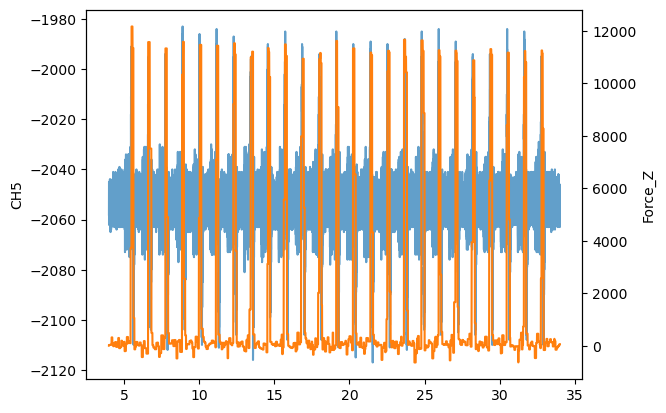

In [313]:
t0_sensor, t1_sensor = 4, 34
n0_sensor, n1_sensor = int(t0_sensor * fs), int(t1_sensor * fs)

n0, n1 = n0_sensor, n1_sensor
# plot ch5 and force_z on left and right y-axix
fig, ax1 = plt.subplots()

time = np.arange(n0_sensor, n1_sensor) / fs

# Left y-axis
ax1.plot(time, pdf["CH5"].iloc[n0:n1], label="CH5", color="tab:blue", alpha=0.7)
ax1.set_ylabel("CH5")

# Right y-axis
ax2 = ax1.twinx()
ax2.plot(time, pdf["Force_Z"].iloc[n0:n1], label="Force_Z", color="tab:orange")
ax2.set_ylabel("Force_Z")

plt.show()

In [314]:
min_height = 40 if (dz < 150) else 50
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500, CHS=["CH5"])

poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=50.0)
force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
print(f"dz={dz}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")

# features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=100.0)

# peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.98)

dz=250, detected 25 pokes, force peaks: 25


[ 60  34  72  77  97  85  73 150  41  11 106 106  29  33  13 102 -20  25
  31  12  82  84 101  73  47]


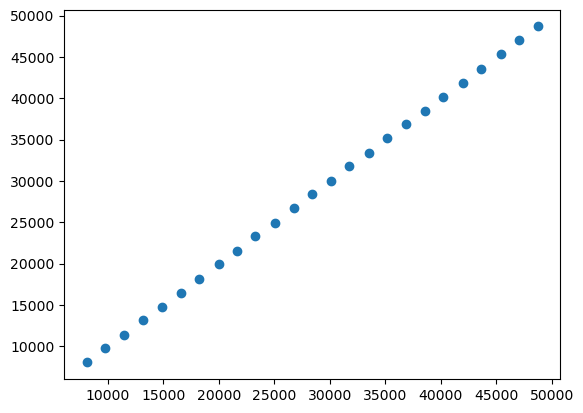

In [316]:
plt.plot(force_peaks, final_peaks, "o")
print(force_peaks-final_peaks)

In [348]:
events = annotate_pokes_from_peaks(final_peaks, mixed_pos, fs)
poke_windows = extract_poke_windows_from_annotations(pdf_trim, events, fs, pad_pre_ms=150, pad_post_ms=300.0)

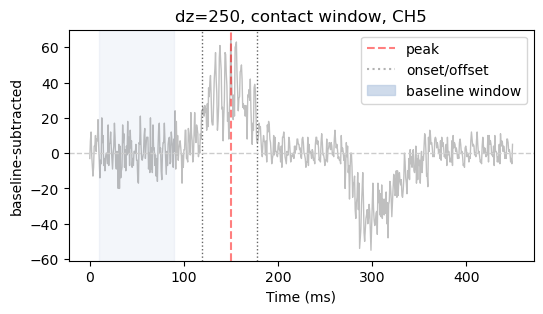

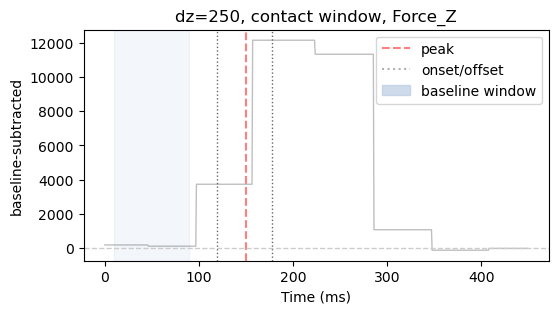

In [349]:
f = plot_poke_windows(poke_windows, fs, ch="CH5", n=1,
                      title=f"dz={dz}, contact window, CH5")

f = plot_poke_windows(poke_windows, fs, ch="Force_Z", n=1,
                      title=f"dz={dz}, contact window, Force_Z")

In [340]:
# f = plot_poke_windows(poke_windows, fs, ch="Force_Z", n=1,
#                       title=f"dz={dz}, contact window, CH5")
# ax = f.axes[0]
# ax.set_title("Contact window, CH5")

### integrate poke signals

In [350]:
results = integrate_poke_session(poke_windows, fs, ch="CH5", cutoff_hz=40.0, filt_order=4)

In [351]:
results[0]["force_window"].columns

Index(['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'Force_Z', 'CH5_dFdT_raw',
       'CH5_F_raw', 'CH5_dFdT_slow', 'CH5_F_slow', 'CH5_dFdT_fast',
       'CH5_F_fast'],
      dtype='object')

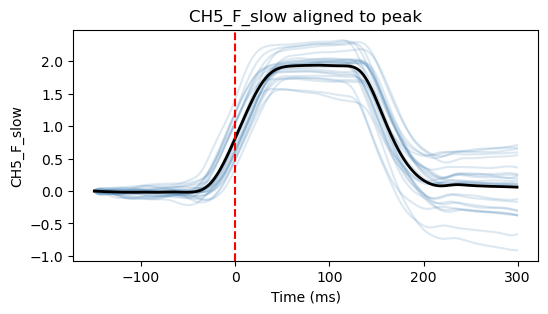

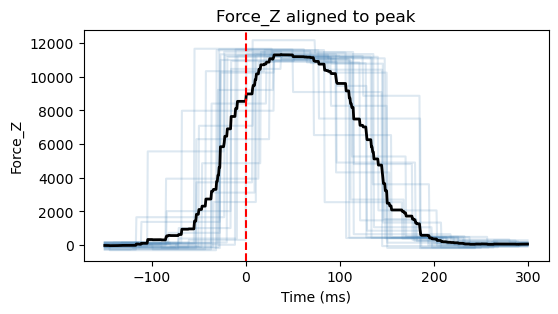

In [352]:
_ = plot_force_windows(results, fs, col="CH5_F_slow")
_ = plot_force_windows(results, fs, col="Force_Z")


In [333]:
def collect_measure_from_results(results, col):
    measures = []
    for res in results:
        force_window = res["force_window"]
        measure = force_window[col]
        measures.extend(measure)
    return np.array(measures)

In [ ]:
plt.scatter()

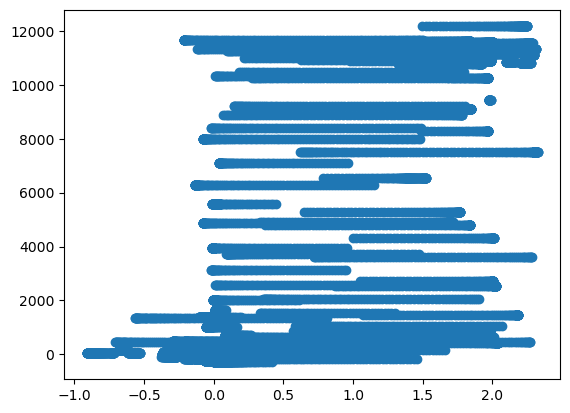

In [334]:
ch5 = collect_measure_from_results(results, "CH5_F_slow")
force = collect_measure_from_results(results, "Force_Z")
plt.scatter(ch5, force)